# Семинар 2. Постановка задачи и baseline'ы

**Продолжительность**: 1-1.5 часа.

**Цели**:
- построить временной train/val/test split без утечек;
- определить positive-события;
- реализовать четыре baseline: random, most popular, recent popular, popular by segment;
- собрать первый честный evaluation pipeline и сравнить модели.

## 1. Импорты

In [1]:
import os
import io
import zipfile
import urllib.request
import warnings
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import random
random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)


In [2]:
def try_download_movielens_100k(cache_dir='../../assets/data'):
    '''Пытается скачать MovieLens 100K; при ошибке — None.'''
    os.makedirs(cache_dir, exist_ok=True)
    zip_path = os.path.join(cache_dir, 'ml-100k.zip')
    extract_dir = os.path.join(cache_dir, 'ml-100k')
    ratings_file = os.path.join(extract_dir, 'u.data')
    if os.path.exists(ratings_file):
        return ratings_file
    url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(cache_dir)
        return ratings_file if os.path.exists(ratings_file) else None
    except Exception as e:
        print(f'Не удалось скачать: {e}')
        return None


def generate_synthetic_interactions(n_users=500, n_items=800, n_events=30000, seed=RANDOM_STATE):
    '''Синтетический fallback с длинным хвостом и латентной структурой.'''
    rng = np.random.default_rng(seed)
    # степенное распределение популярности
    item_popularity = rng.pareto(1.2, n_items) + 1
    item_popularity /= item_popularity.sum()
    user_activity = rng.pareto(1.1, n_users) + 1
    user_activity /= user_activity.sum()

    users = rng.choice(n_users, size=n_events, p=user_activity)
    items = rng.choice(n_items, size=n_events, p=item_popularity)
    # Латентные факторы: 5 «жанров»
    latent_dim = 5
    U = rng.normal(0, 1, (n_users, latent_dim))
    V = rng.normal(0, 1, (n_items, latent_dim))
    user_bias = rng.normal(0, 0.3, n_users)
    item_bias = rng.normal(0, 0.3, n_items)
    scores = (U[users] * V[items]).sum(axis=1) * 0.3
    ratings = 3 + user_bias[users] + item_bias[items] + scores + rng.normal(0, 0.4, n_events)
    ratings = np.clip(np.round(ratings), 1, 5).astype(int)
    ts_start = 1_500_000_000
    timestamps = ts_start + rng.integers(0, 3_600 * 24 * 200, size=n_events)
    df = pd.DataFrame({
        'user_id': users.astype(int),
        'item_id': items.astype(int),
        'rating': ratings,
        'timestamp': timestamps,
    })
    df = df.drop_duplicates(subset=['user_id', 'item_id'])
    return df.sort_values('timestamp').reset_index(drop=True)


def load_interactions():
    path = try_download_movielens_100k()
    if path is not None:
        cols = ['user_id', 'item_id', 'rating', 'timestamp']
        df = pd.read_csv(path, sep='\t', names=cols)
        print(f'MovieLens 100K: {len(df)} interactions, users={df.user_id.nunique()}, items={df.item_id.nunique()}')
        return df
    print('Используем синтетический датасет.')
    df = generate_synthetic_interactions()
    print(f'Synthetic: {len(df)} interactions, users={df.user_id.nunique()}, items={df.item_id.nunique()}')
    return df

df = load_interactions()
df.head()


MovieLens 100K: 100000 interactions, users=943, items=1682


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 2. Split: временной vs. случайный

In [3]:
def temporal_split(df, test_frac=0.2, val_frac=0.0):
    df_sorted = df.sort_values('timestamp')
    n = len(df_sorted)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    train = df_sorted.iloc[:n - n_test - n_val].copy()
    val   = df_sorted.iloc[n - n_test - n_val: n - n_test].copy()
    test  = df_sorted.iloc[n - n_test:].copy()
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train, val, test = temporal_split(df, test_frac=0.2, val_frac=0.1)
print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')
assert train['timestamp'].max() <= val['timestamp'].min() if len(val) else True
assert (val['timestamp'].max() if len(val) else train['timestamp'].max()) <= test['timestamp'].min()
print('OK: без утечек по времени.')


Train: 70000, Val: 10000, Test: 20000
OK: без утечек по времени.


## 3. Positive-события

In [4]:
def positives(df, threshold=4):
    if 'rating' in df.columns and df['rating'].max() > 1:
        return df[df['rating'] >= threshold].copy()
    return df.copy()

train_pos = positives(train)
val_pos   = positives(val)
test_pos  = positives(test)

train_seen_by_user = train.groupby('user_id')['item_id'].apply(set).to_dict()
test_by_user = test_pos.groupby('user_id')['item_id'].apply(set).to_dict()
val_by_user  = val_pos.groupby('user_id')['item_id'].apply(set).to_dict()
print(f'Positive train: {len(train_pos)}, val: {len(val_pos)}, test: {len(test_pos)}')


Positive train: 38968, val: 5104, test: 11303


## 4. Метрики

In [5]:
def precision_at_k(recs, ground_truth, k=10):
    hits = sum(1 for i in recs[:k] if i in ground_truth)
    return hits / k

def recall_at_k(recs, ground_truth, k=10):
    if not ground_truth:
        return 0.0
    hits = sum(1 for i in recs[:k] if i in ground_truth)
    return hits / len(ground_truth)

def hit_rate_at_k(recs, ground_truth, k=10):
    return 1.0 if any(i in ground_truth for i in recs[:k]) else 0.0

def mrr_at_k(recs, ground_truth, k=10):
    for pos, i in enumerate(recs[:k], start=1):
        if i in ground_truth:
            return 1.0 / pos
    return 0.0

def dcg_at_k(recs, ground_truth, k=10):
    return sum(1.0 / np.log2(pos + 1) for pos, i in enumerate(recs[:k], start=1) if i in ground_truth)

def ndcg_at_k(recs, ground_truth, k=10):
    if not ground_truth:
        return 0.0
    dcg = dcg_at_k(recs, ground_truth, k)
    idcg = sum(1.0 / np.log2(pos + 1) for pos in range(1, min(len(ground_truth), k) + 1))
    return dcg / idcg if idcg > 0 else 0.0

def average_precision_at_k(recs, gt, k):
    if not gt: return 0.0
    hits = 0; ap = 0.0
    for pos, i in enumerate(recs[:k], start=1):
        if i in gt:
            hits += 1
            ap += hits / pos
    return ap / min(len(gt), k)

def evaluate(reco_fn, test_by_user, users, k=10, extra_metrics=None):
    metrics = defaultdict(list)
    reco_by_user = {}
    for u in users:
        gt = test_by_user.get(u, set())
        if not gt:
            continue
        recs = reco_fn(u, k)
        reco_by_user[u] = recs
        metrics['precision'].append(precision_at_k(recs, gt, k))
        metrics['recall'].append(recall_at_k(recs, gt, k))
        metrics['hr'].append(hit_rate_at_k(recs, gt, k))
        metrics['mrr'].append(mrr_at_k(recs, gt, k))
        metrics['ndcg'].append(ndcg_at_k(recs, gt, k))
        metrics['map'].append(average_precision_at_k(recs, gt, k))
    out = {m: float(np.mean(v)) for m, v in metrics.items()}
    return out, reco_by_user

def catalog_coverage(reco_by_user, catalog):
    if not catalog: return 0.0
    seen = set()
    for r in reco_by_user.values():
        seen.update(r)
    return len(seen & set(catalog)) / len(catalog)

def novelty(reco_by_user, item_popularity, k=10):
    total = sum(item_popularity.values())
    if total == 0: return 0.0
    p = {i: c / total for i, c in item_popularity.items()}
    vals = []
    for recs in reco_by_user.values():
        s = 0.0
        for i in recs[:k]:
            s += -np.log2(p.get(i, 1e-9))
        vals.append(s / max(1, len(recs[:k])))
    return float(np.mean(vals)) if vals else 0.0

def bootstrap_ci(values, n_boot=200, alpha=0.05, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    arr = np.asarray(values, dtype=float)
    if len(arr) == 0: return (0.0, 0.0, 0.0)
    boots = np.array([rng.choice(arr, size=len(arr), replace=True).mean() for _ in range(n_boot)])
    lo = float(np.quantile(boots, alpha / 2))
    hi = float(np.quantile(boots, 1 - alpha / 2))
    return float(arr.mean()), lo, hi


## 5. Baseline 1. Random

In [6]:
all_items = train.item_id.unique()
rng = np.random.default_rng(RANDOM_STATE)

def random_reco(u, k=10):
    seen = train_seen_by_user.get(u, set())
    candidates = np.setdiff1d(all_items, list(seen), assume_unique=False)
    if len(candidates) <= k:
        return list(candidates)
    return list(rng.choice(candidates, size=k, replace=False))

users_eval = list(test_by_user.keys())
m_rand, reco_rand = evaluate(random_reco, test_by_user, users_eval, k=10)
print('Random:', m_rand)


Random: {'precision': 0.024482758620689656, 'recall': 0.00852325543483446, 'hr': 0.1896551724137931, 'mrr': 0.06724822112753145, 'ndcg': 0.027830907029097275, 'map': 0.011962780514504653}


## 6. Baseline 2. Most popular

In [7]:
popularity = train.groupby('item_id').size().sort_values(ascending=False)
popular_items = popularity.index.tolist()

def most_popular_reco(u, k=10):
    seen = train_seen_by_user.get(u, set())
    return [i for i in popular_items if i not in seen][:k]

m_pop, reco_pop = evaluate(most_popular_reco, test_by_user, users_eval, k=10)
print('Most popular:', m_pop)


Most popular: {'precision': 0.22655172413793104, 'recall': 0.08188890154618467, 'hr': 0.7517241379310344, 'mrr': 0.441143951833607, 'ndcg': 0.25045125042289307, 'map': 0.1426574855996038}


## 7. Baseline 3. Recent popular

In [8]:
tmax = train['timestamp'].max()
recent_window = 60 * 60 * 24 * 30
recent = train[train['timestamp'] >= tmax - recent_window]
recent_items = recent.groupby('item_id').size().sort_values(ascending=False).index.tolist()

def recent_popular_reco(u, k=10):
    seen = train_seen_by_user.get(u, set())
    return [i for i in recent_items if i not in seen][:k]

m_rec, reco_rec = evaluate(recent_popular_reco, test_by_user, users_eval, k=10)
print('Recent popular:', m_rec)


Recent popular: {'precision': 0.24310344827586206, 'recall': 0.11577548085163582, 'hr': 0.7793103448275862, 'mrr': 0.5189586754241927, 'ndcg': 0.289508091920086, 'map': 0.1699285486225141}


## 8. Baseline 4. Popular by segment

In [9]:
user_activity = train.groupby('user_id').size()
segments = pd.qcut(user_activity, q=3, labels=['low', 'mid', 'high'])
user_segment = segments.to_dict()

seg_pop = {}
for s in ['low', 'mid', 'high']:
    seg_users = [u for u, seg in user_segment.items() if seg == s]
    seg_df = train[train.user_id.isin(seg_users)]
    seg_pop[s] = seg_df.groupby('item_id').size().sort_values(ascending=False).index.tolist()

def segment_reco(u, k=10):
    seg = user_segment.get(u, 'mid')
    seen = train_seen_by_user.get(u, set())
    return [i for i in seg_pop[seg] if i not in seen][:k]

m_seg, reco_seg = evaluate(segment_reco, test_by_user, users_eval, k=10)
print('Popular by segment:', m_seg)


Popular by segment: {'precision': 0.21620689655172415, 'recall': 0.06887070389522466, 'hr': 0.696551724137931, 'mrr': 0.4452627257799671, 'ndcg': 0.24046296053822427, 'map': 0.13962668764823938}


## 9. Сводная таблица

In [10]:
catalog = set(all_items)
item_pop_dict = train.groupby('item_id').size().to_dict()

def add_extras(name, metrics, reco_by_user):
    metrics = dict(metrics)
    metrics['coverage'] = catalog_coverage(reco_by_user, catalog)
    metrics['novelty'] = novelty(reco_by_user, item_pop_dict, k=10)
    return {'model': name, **metrics}

rows = [
    add_extras('random', m_rand, reco_rand),
    add_extras('most popular', m_pop, reco_pop),
    add_extras('recent popular', m_rec, reco_rec),
    add_extras('popular by segment', m_seg, reco_seg),
]
summary = pd.DataFrame(rows).set_index('model').round(4)
summary


,precision,recall,hr,mrr,ndcg,map,coverage,novelty
model,,,,,,,,
random,0.0245,0.0085,0.1897,0.0672,0.0278,0.0120,0.8347,12.0489
most popular,0.2266,0.0819,0.7517,0.4411,0.2505,0.1427,0.0432,7.7287
recent popular,0.2431,0.1158,0.7793,0.5190,0.2895,0.1699,0.0375,7.9700
popular by segment,0.2162,0.0689,0.6966,0.4453,0.2405,0.1396,0.0636,7.7882


## 10. Bootstrap-интервал для NDCG@10

In [11]:
def per_user_ndcg(reco_by_user, test_by_user, k=10):
    return [ndcg_at_k(reco_by_user[u], test_by_user[u], k) for u in reco_by_user if test_by_user.get(u)]

for name, reco in [('random', reco_rand), ('popular', reco_pop),
                   ('recent popular', reco_rec), ('by segment', reco_seg)]:
    m, lo, hi = bootstrap_ci(per_user_ndcg(reco, test_by_user))
    print(f'{name:>18}: NDCG@10 = {m:.4f}  CI95 = [{lo:.4f}, {hi:.4f}]')


            random: NDCG@10 = 0.0278  CI95 = [0.0177, 0.0377]
           popular: NDCG@10 = 0.2505  CI95 = [0.2238, 0.2755]
    recent popular: NDCG@10 = 0.2895  CI95 = [0.2669, 0.3154]
        by segment: NDCG@10 = 0.2405  CI95 = [0.2132, 0.2649]


## 11. Влияние K

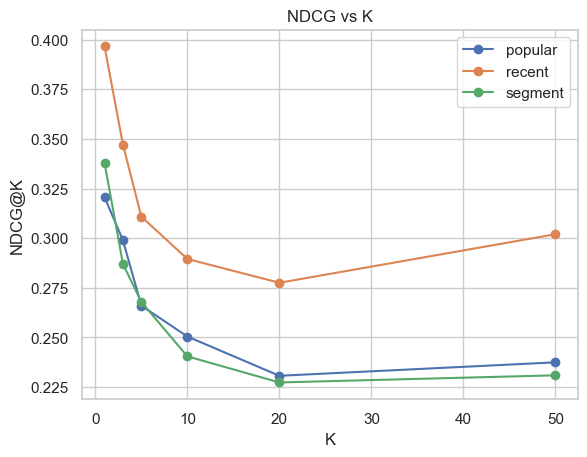

In [12]:
ks = [1, 3, 5, 10, 20, 50]
ndcg_curves = {'popular': [], 'recent': [], 'segment': []}
for k in ks:
    m, r = evaluate(most_popular_reco, test_by_user, users_eval, k=k); ndcg_curves['popular'].append(m['ndcg'])
    m, r = evaluate(recent_popular_reco, test_by_user, users_eval, k=k); ndcg_curves['recent'].append(m['ndcg'])
    m, r = evaluate(segment_reco, test_by_user, users_eval, k=k); ndcg_curves['segment'].append(m['ndcg'])
for name, y in ndcg_curves.items():
    plt.plot(ks, y, marker='o', label=name)
plt.xlabel('K'); plt.ylabel('NDCG@K'); plt.title('NDCG vs K'); plt.legend(); plt.show()


## Задача 1. Popular by weekday

Реализуйте baseline `popular_by_weekday`: для каждого дня недели своя популярность. При запросе — берём популярность того дня, когда запрос сделан.

In [ ]:
# YOUR CODE HERE
# 1) Из train вычислите weekday
# 2) Для каждого weekday постройте свой sorted список
# 3) Опишите функцию wd_reco(u, k, current_wd)


In [13]:
# 1) Из train вычислите weekday
# Переводим timestamp (в секундах) в формат datetime и берем день недели (0 - понедельник, 6 - воскресенье)
train['weekday'] = pd.to_datetime(train['timestamp'], unit='s').dt.weekday

# 2) Для каждого weekday постройте свой sorted список
wd_pop = {}
for wd in range(7):
    # Отфильтруем взаимодействия для конкретного дня недели
    wd_df = train[train['weekday'] == wd]
    # Считаем популярность (количество взаимодействий с item_id) и сохраняем отсортированный список
    wd_pop[wd] = wd_df.groupby('item_id').size().sort_values(ascending=False).index.tolist()

# 3) Опишите функцию wd_reco(u, k, current_wd)
def wd_reco(u, k=10, current_wd=0):
    # Получаем товары, с которыми пользователь уже взаимодействовал
    seen = train_seen_by_user.get(u, set())

    # Получаем кандидатов для текущего дня недели.
    # В качестве fallback (если данных для дня почему-то нет) используем общий список popular_items
    candidates = wd_pop.get(current_wd, popular_items)
    if not candidates:
        candidates = popular_items

    # Возвращаем топ-k кандидатов, которых нет в просмотренных
    return [i for i in candidates if i not in seen][:k]


# Пример использования функции:
# Получим 5 рекомендаций для пользователя 1 для среды (день 2)
print(wd_reco(u=1, k=5, current_wd=2))

[288, 294, 286, 300, 405]


## Задача 2. Отсутствие filter seen

Что случится, если мы **не** будем фильтровать уже увиденные объекты? Прогоните `most popular` без фильтра.

In [ ]:
# YOUR CODE HERE
# определите reco без фильтрации seen и оцените


In [14]:
# reco без фильтрации seen
def unfiltered_reco(u, k=10):
    # Просто берем глобальный топ популярных айтемов без оглядки на seen
    return popular_items[:k]

# Оцениваем на тех же тестовых пользователях
m_unf, reco_unf = evaluate(unfiltered_reco, test_by_user, users_eval, k=10)

print('Unfiltered popular:', m_unf)

# Для наглядности можно сравнить с Most popular (с фильтрацией)
m_pop, _ = evaluate(most_popular_reco, test_by_user, users_eval, k=10)
print('Filtered popular (baseline):', m_pop)

Unfiltered popular: {'precision': 0.2120689655172414, 'recall': 0.07339070079326794, 'hr': 0.7068965517241379, 'mrr': 0.4162876299945265, 'ndcg': 0.2322280931140144, 'map': 0.13061504352698933}
Filtered popular (baseline): {'precision': 0.22655172413793104, 'recall': 0.08188890154618467, 'hr': 0.7517241379310344, 'mrr': 0.441143951833607, 'ndcg': 0.25045125042289307, 'map': 0.1426574855996038}


## Задача 3. Random split → показать утечку

Сравните NDCG для random split (без учёта времени) и temporal split. Прокомментируйте.

In [ ]:
# YOUR CODE HERE
# 1) сделайте случайный split
# 2) обучите popular и оцените
# 3) сравните с temporal split


In [15]:
# 1) сделайте случайный split
def random_split(df, test_frac=0.2, val_frac=0.1, seed=RANDOM_STATE):
    # Перемешиваем данные
    df_shuffled = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(df_shuffled)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    rand_train = df_shuffled.iloc[:n - n_test - n_val].copy()
    rand_val   = df_shuffled.iloc[n - n_test - n_val: n - n_test].copy()
    rand_test  = df_shuffled.iloc[n - n_test:].copy()
    return rand_train, rand_val, rand_test

rand_train, rand_val, rand_test = random_split(df)

# Подготавливаем тестовые данные (ground truth) и seen (для фильтрации)
rand_train_seen_by_user = rand_train.groupby('user_id')['item_id'].apply(set).to_dict()
rand_test_pos = positives(rand_test)
rand_test_by_user = rand_test_pos.groupby('user_id')['item_id'].apply(set).to_dict()
rand_users_eval = list(rand_test_by_user.keys())

# 2) обучите popular и оцените
# Считаем популярность айтемов на случайном train
rand_popularity = rand_train.groupby('item_id').size().sort_values(ascending=False)
rand_popular_items = rand_popularity.index.tolist()

def rand_most_popular_reco(u, k=10):
    seen = rand_train_seen_by_user.get(u, set())
    return [i for i in rand_popular_items if i not in seen][:k]

m_rand_pop, _ = evaluate(rand_most_popular_reco, rand_test_by_user, rand_users_eval, k=10)

# 3) сравните с temporal split
print('# Сравнение метрик')
print('Temporal Split (честный): ', {k: round(v, 4) for k, v in m_pop.items()})
print('Random Split   (с утечкой):', {k: round(v, 4) for k, v in m_rand_pop.items()})

diff = m_rand_pop['ndcg'] - m_pop['ndcg']
print(f'\n# Разница в NDCG@10: {diff:+.4f}')

# Сравнение метрик
Temporal Split (честный):  {'precision': 0.2266, 'recall': 0.0819, 'hr': 0.7517, 'mrr': 0.4411, 'ndcg': 0.2505, 'map': 0.1427}
Random Split   (с утечкой): {'precision': 0.1181, 'recall': 0.1281, 'hr': 0.6364, 'mrr': 0.2896, 'ndcg': 0.1509, 'map': 0.0715}

# Разница в NDCG@10: -0.0995


## 12. Итоги

- Временной split — стандарт индустрии; random split приводит к утечкам.
- Filter seen — обязательный шаг перед оценкой.
- Один только NDCG не показывает картины: нужны coverage/novelty.

## Что дальше

Тема 3: коллаборативная фильтрация. Учимся ловить «общие» вкусы и делать первый большой шаг вперёд от baseline.